In [2]:
import pandas as pd

In [3]:
from google.colab import files
uploaded = files.upload()

Saving dim_terminal.csv to dim_terminal.csv
Saving dim_time.csv to dim_time.csv
Saving dim_vessel.csv to dim_vessel.csv
Saving fact_cargo_movements.csv to fact_cargo_movements.csv


In [4]:
terminal = pd.read_csv("dim_terminal.csv")
vessel = pd.read_csv("dim_vessel.csv")
facts = pd.read_csv("fact_cargo_movements.csv")
time = pd.read_csv("dim_time.csv")

In [5]:
terminal.head()

,terminal_id,terminal_name,port_location,regional_hub
0,778,Shannon Gray,"{""type"":""Point"",""coordinates"":[-98.93604,-58.4...",APAC
1,672,Deborah Perez,"{""type"":""Point"",""coordinates"":[105.481792,-25....",AMER
2,930,Regina White,"{""type"":""Point"",""coordinates"":[125.221272,-3.8...",EMEA
3,961,Luke Jones,"{""type"":""Point"",""coordinates"":[178.136717,-63....",APAC
4,705,Mercedes Miller,"{""type"":""Point"",""coordinates"":[134.248326,-40....",EMEA


In [6]:
vessel.head()

,vessel_key,vessel_id,vessel_name,vessel_category,build_year
0,Passenger_89,89,Brenda Soto,Passenger,2008
1,Container_774,774,Susan Garrett,Container,1907
2,Container_655,655,Stephanie Johnson,Container,1949
3,Passenger_439,439,Laura Williams,Passenger,1956
4,Tanker_433,433,Steven Mack,Tanker,1998


In [7]:
facts.head()

,movement_id,date_id,vessel_key,vessel_id,vessel_category,terminal_id,container_count,move_duration,route_geometry
0,637,2024-07-28,Cargo_833,833,Cargo,197,415,211.682852,"{'type': 'LineString', 'coordinates': [[7.5099..."
1,266,2022-03-18,Passenger_847,84,Passenger,490,342,832.519929,"{'type': 'LineString', 'coordinates': [[7.5099..."
2,601,2022-02-15,Tanker_65,65,Tanker,99,115,613.992116,"{'type': 'LineString', 'coordinates': [[7.5099..."
3,274,2023-12-08,Tanker_179,179,Tanker,197,55,69.302117,"{'type': 'LineString', 'coordinates': [[7.5099..."
4,118,2024-06-25,Passenger_49,49,Passenger,490,695,862.709349,"{'type': 'LineString', 'coordinates': [[7.5099..."


In [8]:
time.head()

,date_id,fiscal_year,quarter,month,week,shift
0,2021-01-01,2021,1,1,53,Day
1,2021-01-02,2021,1,1,53,Night
2,2021-01-03,2021,1,1,53,Day
3,2021-01-04,2021,1,1,1,Day
4,2021-01-05,2021,1,1,1,Day


In [9]:
terminal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   terminal_id    50 non-null     int64 
 1   terminal_name  50 non-null     object
 2   port_location  50 non-null     object
 3   regional_hub   50 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.7+ KB


In [10]:
time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date_id      1461 non-null   object
 1   fiscal_year  1461 non-null   int64 
 2   quarter      1461 non-null   int64 
 3   month        1461 non-null   int64 
 4   week         1461 non-null   int64 
 5   shift        1461 non-null   object
dtypes: int64(4), object(2)
memory usage: 68.6+ KB


In [11]:
vessel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   vessel_key       1000 non-null   object
 1   vessel_id        1000 non-null   int64 
 2   vessel_name      1000 non-null   object
 3   vessel_category  1000 non-null   object
 4   build_year       1000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 39.2+ KB


In [12]:
facts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movement_id      15000 non-null  int64  
 1   date_id          15000 non-null  object 
 2   vessel_key       15000 non-null  object 
 3   vessel_id        15000 non-null  int64  
 4   vessel_category  15000 non-null  object 
 5   terminal_id      15000 non-null  int64  
 6   container_count  15000 non-null  int64  
 7   move_duration    15000 non-null  float64
 8   route_geometry   15000 non-null  object 
dtypes: float64(1), int64(4), object(4)
memory usage: 1.0+ MB


#Step 2: Referential Integrity Check
**Objective:** To validate inclusion dependencies, ensuring that all foreign keys in the fact table exist in their corresponding dimension tables

In [13]:
#Checking vessel
missing_vessels = set(facts["vessel_id"]) - set(vessel["vessel_id"])
missing_vessels

set()

In [14]:
#check terminal
missing_terminal = set(facts["terminal_id"]) - set(terminal["terminal_id"])
missing_terminal


set()

In [15]:
#check date
missing_date = set(facts["date_id"]) - set(time["date_id"])
missing_date

set()

#Interpretation

All inclusion dependency checks returned empty sets, indicating that:

Every vessel_id in the fact table exists in dim_vessel
Every terminal_id exists in dim_terminal
Every date_id exists in dim_time

Therefore, referential integrity is fully maintained across all relationships in this dataset.

#Step 3: Functional Deficiency Check
**Objective:** To validate that key attributes uniquely determine dependent attributes within dimension tables.

In [16]:
#checking vessel consistency
vessel_check = vessel.groupby("vessel_id").nunique()
vessel_check

,vessel_key,vessel_name,vessel_category,build_year
vessel_id,,,,
4,2,2,2,2
5,3,3,2,2
6,1,1,1,1
7,3,3,2,3
9,1,1,1,1
...,...,...,...,...
995,1,1,1,1
997,2,2,2,2
998,1,1,1,1


In [17]:
#checking terminal consistency
terminal_check = terminal.groupby("terminal_id").nunique()
terminal_check

,terminal_name,port_location,regional_hub
terminal_id,,,
45,1,1,1
99,1,1,1
110,1,1,1
113,1,1,1
131,1,1,1
154,1,1,1
169,1,1,1
189,1,1,1
197,1,1,1


In [18]:
date_check = time.groupby("date_id").nunique()
date_check

,fiscal_year,quarter,month,week,shift
date_id,,,,,
2021-01-01,1,1,1,1,1
2021-01-02,1,1,1,1,1
2021-01-03,1,1,1,1,1
2021-01-04,1,1,1,1,1
2021-01-05,1,1,1,1,1
...,...,...,...,...,...
2024-12-27,1,1,1,1,1
2024-12-28,1,1,1,1,1
2024-12-29,1,1,1,1,1


The analysis reveals violations of functional dependencies within the dim_vessel table, where a single vessel_id maps to multiple attribute values, indicating inconsistencies in entity representation.

#Step 5: Investigating the Problem
**Objectives:** To identify and analyze incostistent records causing functional dependency violations.



In [19]:
problem_vessels = vessel.groupby("vessel_id").filter(
    lambda x: x["vessel_name"].nunique()>1
    )
problem_vessels

,vessel_key,vessel_id,vessel_name,vessel_category,build_year
2,Container_655,655,Stephanie Johnson,Container,1949
3,Passenger_439,439,Laura Williams,Passenger,1956
5,Passenger_859,859,Jennifer Ortiz,Passenger,1915
6,Passenger_86,86,Lori Smith,Passenger,1953
7,Container_698,698,Margaret Foster,Container,1918
...,...,...,...,...,...
988,Tanker_246,246,Stanley Higgins,Tanker,2012
993,Container_431,431,Dr. Haley Solis,Container,2006
997,Passenger_361,361,Rachel Mcneil,Passenger,1943
998,Cargo_962,962,Barbara Vaughn,Cargo,1953


In [20]:
vessel[vessel["vessel_id"] == 4]

,vessel_key,vessel_id,vessel_name,vessel_category,build_year
772,Cargo_4,4,Taylor Harrison,Cargo,1925
900,Container_4,4,Daniel Carlson,Container,1962


In [21]:
# Step 1: Count how many unique values each vessel_id has
fd_check = vessel.groupby("vessel_id").agg({
    "vessel_name": "nunique",
    "vessel_category": "nunique",
    "build_year": "nunique"
})

# Step 2: Find vessels with ANY inconsistency
violations = fd_check[
    (fd_check["vessel_name"] > 1) |
    (fd_check["vessel_category"] > 1) |
    (fd_check["build_year"] > 1)
]

violations.head(50)

,vessel_name,vessel_category,build_year
vessel_id,,,
4,2,2,2
5,3,2,2
7,3,2,3
12,2,2,2
17,2,2,2
21,2,2,2
22,3,2,3
36,2,2,2
37,2,2,2


In [22]:
len(violations)

264

In order to cleam the data on the vessel table, for each vessel_id with more than one attribute, we select the most consistent category below

In [23]:
# Function to get most frequent value
def get_mode(series):
    return series.mode()[0]

# Clean vessel table
clean_vessel = vessel.groupby("vessel_id").agg({
    "vessel_name": get_mode,
    "vessel_category": get_mode,
    "build_year": get_mode
}).reset_index()

clean_vessel

,vessel_id,vessel_name,vessel_category,build_year
0,4,Daniel Carlson,Cargo,1925
1,5,Ashley Garza,Container,1956
2,6,Michael Lane,Passenger,1957
3,7,Nicholas Galvan,Tanker,1916
4,9,Victoria Pace,Container,1970
...,...,...,...,...
631,995,Jennifer Garcia,Cargo,1924
632,997,Ann Cook,Container,1990
633,998,Abigail Lee,Passenger,1923
634,999,Barbara Cook,Passenger,1900


In [24]:
#to check that vessel_id uniquely determine dependent attributes within the dimension table

clean_check = clean_vessel.groupby("vessel_id").nunique()
clean_check.head()

,vessel_name,vessel_category,build_year
vessel_id,,,
4,1,1,1
5,1,1,1
6,1,1,1
7,1,1,1
9,1,1,1


In [25]:
#to cross check that our cleaned vessel data no longer violates functional dependencies

print("Before cleaning:", len(violations))
print("After cleaning:", len(clean_vessel.groupby("vessel_id").filter(lambda x: x.nunique().max() > 1)))

Before cleaning: 264
After cleaning: 0


In [26]:
df = facts.copy()

In [27]:
df = df.merge(clean_vessel, on="vessel_id", how="left")

In [28]:
df = df.merge(terminal, on="terminal_id", how="left")

In [29]:
df = df.merge(time, on="date_id", how="left")

In [30]:
df["vessel_age"] = 2024 - df["build_year"]

In [31]:
df["year_month"] = df["date_id"].astype(str).str[:7]

In [32]:
df.to_csv("maritime_analysis.csv", index=False)

#Starting the Exploratory Data Analysis

In [33]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   movement_id        15000 non-null  int64  
 1   date_id            15000 non-null  object 
 2   vessel_key         15000 non-null  object 
 3   vessel_id          15000 non-null  int64  
 4   vessel_category_x  15000 non-null  object 
 5   terminal_id        15000 non-null  int64  
 6   container_count    15000 non-null  int64  
 7   move_duration      15000 non-null  float64
 8   route_geometry     15000 non-null  object 
 9   vessel_name        15000 non-null  object 
 10  vessel_category_y  15000 non-null  object 
 11  build_year         15000 non-null  int64  
 12  terminal_name      15000 non-null  object 
 13  port_location      15000 non-null  object 
 14  regional_hub       15000 non-null  object 
 15  fiscal_year        15000 non-null  int64  
 16  quarter            150

In [34]:
df.head()

,movement_id,date_id,vessel_key,vessel_id,vessel_category_x,terminal_id,container_count,move_duration,route_geometry,vessel_name,...,terminal_name,port_location,regional_hub,fiscal_year,quarter,month,week,shift,vessel_age,year_month
0,637,2024-07-28,Cargo_833,833,Cargo,197,415,211.682852,"{'type': 'LineString', 'coordinates': [[7.5099...",Jason Mitchell,...,Tammy Strong,"{""type"":""Point"",""coordinates"":[120.645285,52.4...",EMEA,2024,3,7,30,Night,122,2024-07
1,266,2022-03-18,Passenger_847,84,Passenger,490,342,832.519929,"{'type': 'LineString', 'coordinates': [[7.5099...",Dennis Phelps,...,Elizabeth Norman,"{""type"":""Point"",""coordinates"":[-118.872009,-9....",AMER,2022,1,3,11,Night,108,2022-03
2,601,2022-02-15,Tanker_65,65,Tanker,99,115,613.992116,"{'type': 'LineString', 'coordinates': [[7.5099...",David Baker,...,Kayla Mitchell,"{""type"":""Point"",""coordinates"":[-24.294386,66.0...",APAC,2022,1,2,7,Day,79,2022-02
3,274,2023-12-08,Tanker_179,179,Tanker,197,55,69.302117,"{'type': 'LineString', 'coordinates': [[7.5099...",James Walker II,...,Tammy Strong,"{""type"":""Point"",""coordinates"":[120.645285,52.4...",EMEA,2023,4,12,49,Night,101,2023-12
4,118,2024-06-25,Passenger_49,49,Passenger,490,695,862.709349,"{'type': 'LineString', 'coordinates': [[7.5099...",Kyle Moore,...,Elizabeth Norman,"{""type"":""Point"",""coordinates"":[-118.872009,-9....",AMER,2024,2,6,26,Night,76,2024-06


In [35]:
df[['container_count', 'move_duration', 'vessel_age']].describe()

,container_count,move_duration,vessel_age
count,15000.000000,15000.000000,15000.000000
mean,501.334400,501.239874,72.604333
std,287.495224,289.145790,34.285480
min,0.000000,0.027465,1.000000
25%,252.000000,249.948855,45.000000
50%,500.000000,505.347695,76.000000
75%,749.000000,751.720322,103.000000
max,1000.000000,999.993733,124.000000


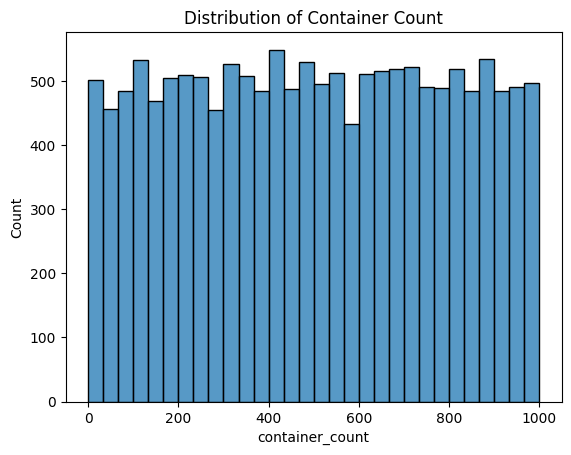

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['container_count'], bins=30)
plt.title("Distribution of Container Count")
plt.show()

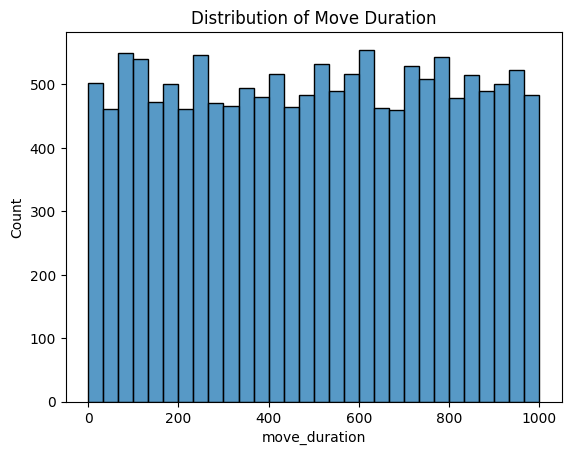

In [37]:
sns.histplot(df['move_duration'], bins=30)
plt.title("Distribution of Move Duration")
plt.show()

In [38]:
monthly = df.groupby('year_month').agg({
    'container_count': 'sum',
    'move_duration': 'mean'
}).reset_index()

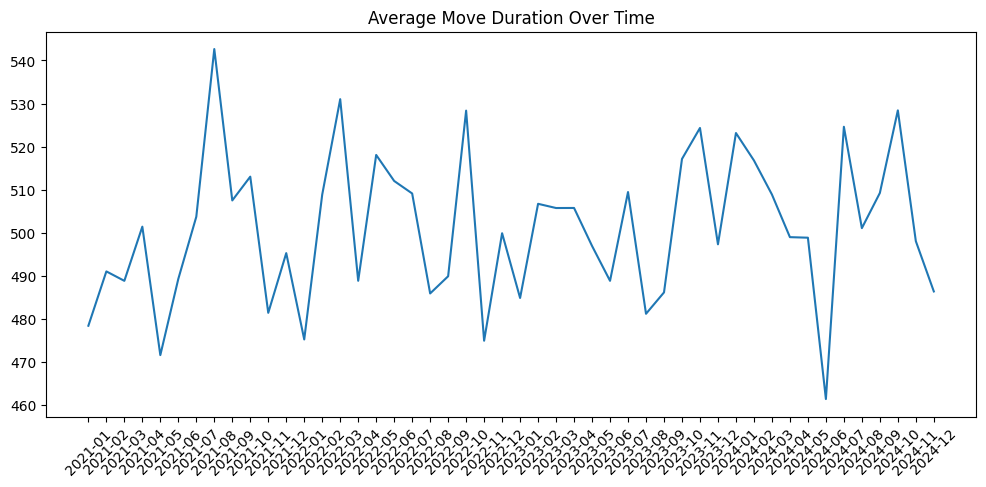

In [39]:
plt.figure(figsize=(12,5))
plt.plot(monthly['year_month'], monthly['move_duration'])
plt.xticks(rotation=45)
plt.title("Average Move Duration Over Time")
plt.show()

In [40]:
terminal_load = df.groupby('terminal_name').agg({
    'container_count': 'sum',
    'move_duration': 'mean'
}).reset_index()

In [41]:
terminal_load.sort_values('container_count', ascending=False).head(10)

,terminal_name,container_count,move_duration
1,Angel Castillo,168610,518.624736
24,Kayla Mitchell,166497,514.337269
25,Lauren Little,159782,520.569336
37,Ryan Williams,159778,514.978786
43,Shawn Martinez,159775,521.802165
17,Jason Gonzalez,159328,505.129245
34,Patricia Gallegos,159268,517.048233
18,Jason Melton,158754,501.068370
5,Courtney Mclaughlin,158407,505.365834
22,John Juarez,158332,488.537343


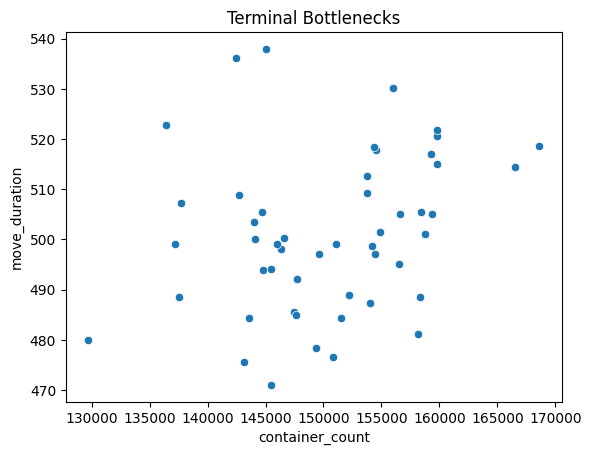

In [42]:
sns.scatterplot(
    data=terminal_load,
    x='container_count',
    y='move_duration'
)
plt.title("Terminal Bottlenecks")
plt.show()

In [43]:
df.groupby('vessel_category_y')['move_duration'].mean()

,move_duration
vessel_category_y,
Cargo,498.890785
Container,495.024318
Passenger,511.871888
Tanker,499.748602


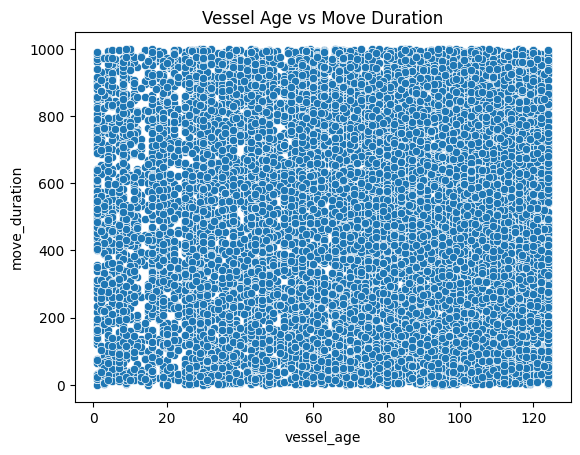

In [44]:
sns.scatterplot(
    data=df,
    x='vessel_age',
    y='move_duration'
)
plt.title("Vessel Age vs Move Duration")
plt.show()

In [45]:
df.groupby('shift')['move_duration'].mean()

,move_duration
shift,
Day,505.724279
Night,496.812505
